# Projekat: Predviđanje `Overall_Health_Score`

Ovaj notebook prikazuje kompletan ML tok za predviđanje ciljne promenljive `Overall_Health_Score` iz fajla `fast_food_consumption_health_impact_dataset.csv`.

Modeli:
1. Linearna regresija
2. Random Forest Regressor
3. Gradient Boosting Regressor
4. SVR

Notebook je podeljen po celinama i sadrži sekciju za čuvanje grafika, matrica konfuzije i tabela za prezentaciju/štampu.

## 1) Uvoz biblioteka i podešavanje okruženja

In [45]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    confusion_matrix,
    accuracy_score,
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Kontejneri za rezultate i figure
results = []
model_predictions = {}
figures = {}
class_accuracies = {}

print("Biblioteke uspesno ucitane.")

Biblioteke uspesno ucitane.


## 2) Učitavanje CSV fajla i inicijalni pregled podataka

In [46]:
DATA_PATH = "fast_food_consumption_health_impact_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
display(df.head())
display(df.dtypes.to_frame("dtype"))
display(df.describe(include="all").transpose())

Shape: (800, 11)


,Age,Gender,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Digestive_Issues,Doctor_Visits_Per_Year,Overall_Health_Score
0,56,Male,1,3153,28.4,4.5,7.8,9,No,7,5
1,46,Male,12,1748,22.8,9.6,6.7,2,No,4,3
2,32,Female,8,3020,21.5,4.0,7.4,2,Yes,7,4
3,25,Female,6,2621,26.8,8.4,6.1,6,No,7,8
4,38,Female,14,2260,18.1,1.9,7.7,7,No,5,4


,dtype
Age,int64
Gender,object
Fast_Food_Meals_Per_Week,int64
Average_Daily_Calories,int64
BMI,float64
Physical_Activity_Hours_Per_Week,float64
Sleep_Hours_Per_Day,float64
Energy_Level_Score,int64
Digestive_Issues,object
Doctor_Visits_Per_Year,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,800.0,NaN,NaN,NaN,38.8025,12.055919,18.0,29.0,40.0,49.0,59.0
Gender,800,3,Male,385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fast_Food_Meals_Per_Week,800.0,NaN,NaN,NaN,6.81875,4.329183,0.0,3.0,7.0,11.0,14.0
Average_Daily_Calories,800.0,NaN,NaN,NaN,2554.72875,551.078974,1600.0,2084.75,2540.5,3049.0,3499.0
BMI,800.0,NaN,NaN,NaN,26.439,4.94144,18.0,22.5,26.4,30.625,35.0
Physical_Activity_Hours_Per_Week,800.0,NaN,NaN,NaN,4.938,2.860272,0.0,2.4,4.9,7.4,10.0
Sleep_Hours_Per_Day,800.0,NaN,NaN,NaN,6.472875,1.429232,4.0,5.2,6.5,7.7,9.0
Energy_Level_Score,800.0,NaN,NaN,NaN,4.90375,2.587538,1.0,3.0,5.0,7.0,9.0
Digestive_Issues,800,2,No,497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor_Visits_Per_Year,800.0,NaN,NaN,NaN,5.64875,3.467045,0.0,3.0,6.0,9.0,11.0


## 3) Čišćenje podataka i obrada nedostajućih vrednosti

In [47]:
duplicates = df.duplicated().sum()
null_counts = df.isna().sum()

print(f"Broj duplikata: {duplicates}")
print("\nNedostajuće vrednosti po kolonama:")
display(null_counts.to_frame("null_count"))

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplikati uklonjeni.")
else:
    print("Nema duplikata za uklanjanje.")

# Lagano čišćenje string kolona (trim)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

print(f"Shape nakon čišćenja: {df.shape}")

Broj duplikata: 0

Nedostajuće vrednosti po kolonama:


,null_count
Age,0
Gender,0
Fast_Food_Meals_Per_Week,0
Average_Daily_Calories,0
BMI,0
Physical_Activity_Hours_Per_Week,0
Sleep_Hours_Per_Day,0
Energy_Level_Score,0
Digestive_Issues,0
Doctor_Visits_Per_Year,0


Nema duplikata za uklanjanje.
Shape nakon čišćenja: (800, 11)


## 4) EDA: distribucije, korelacije i ključni grafici

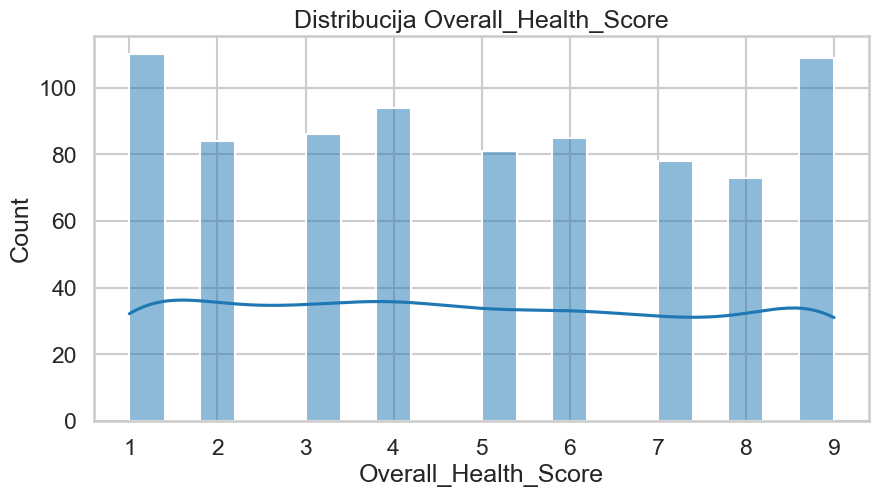

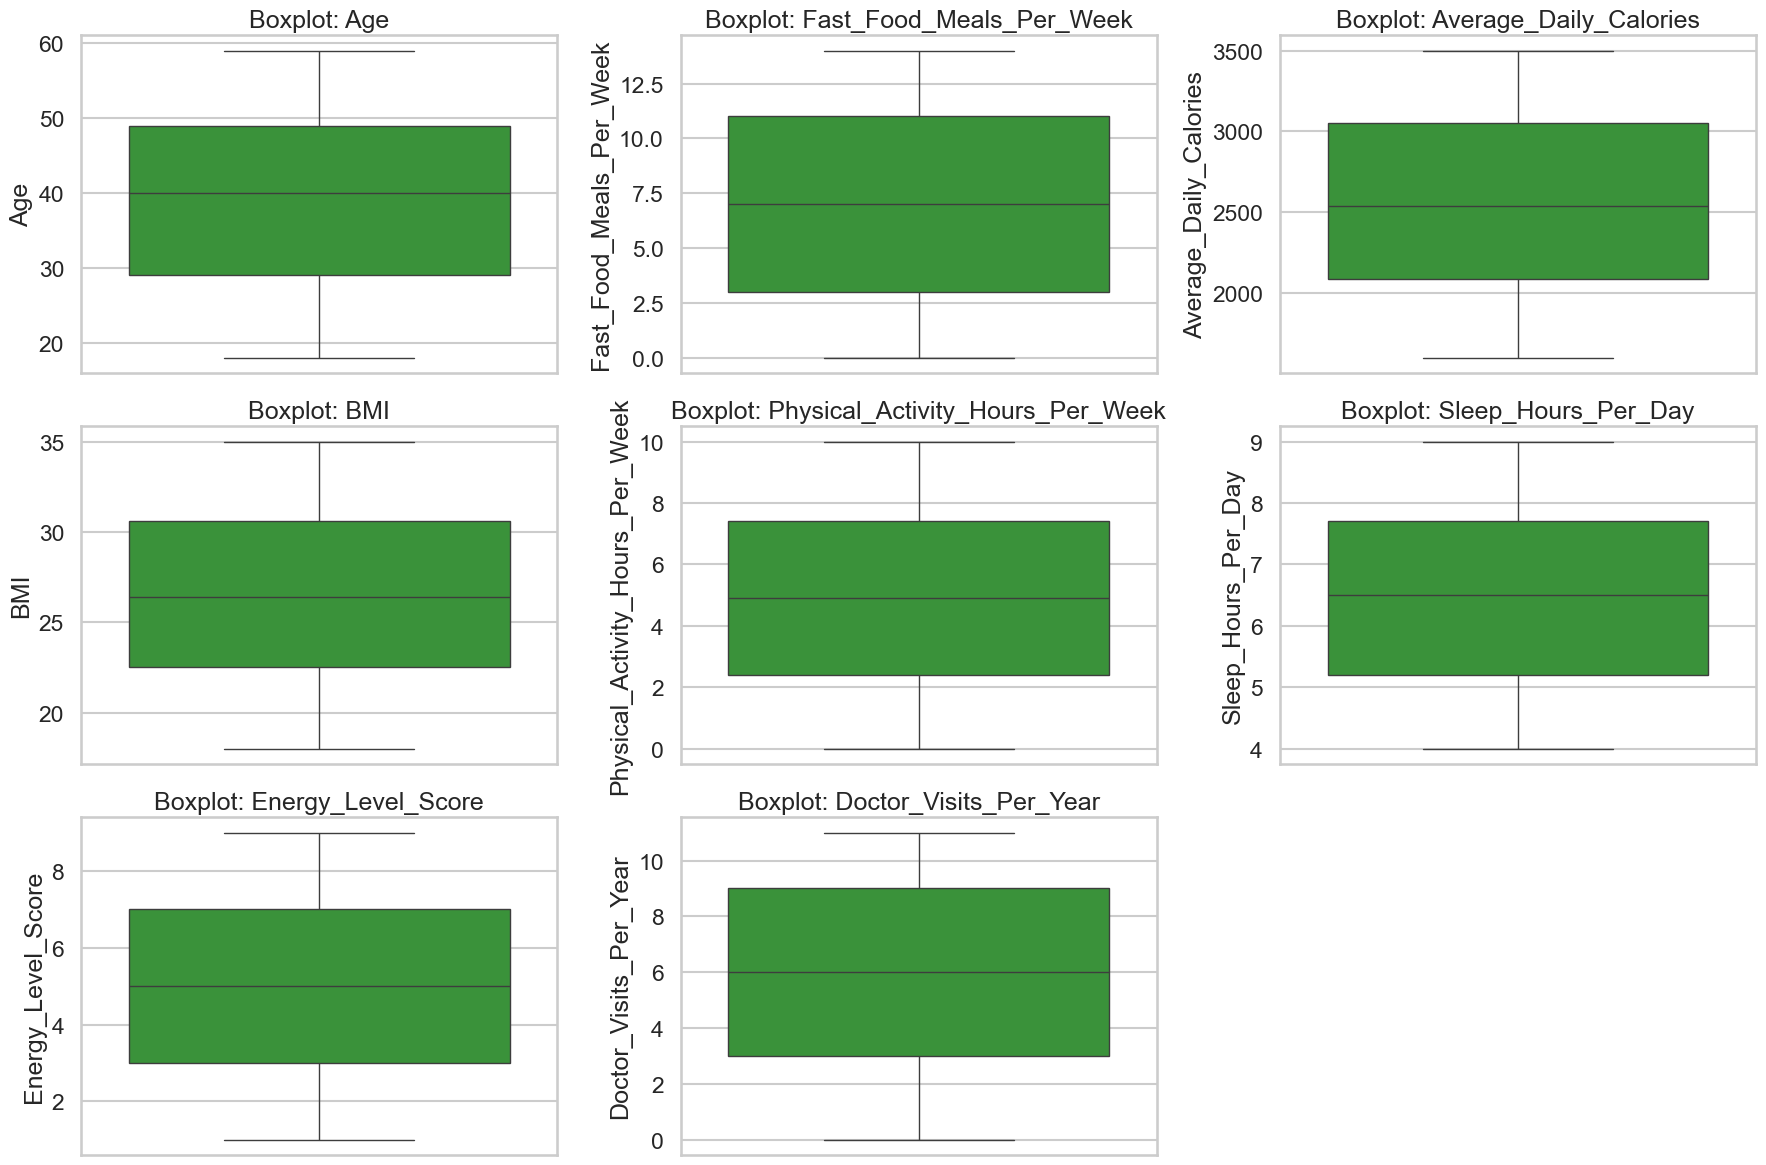

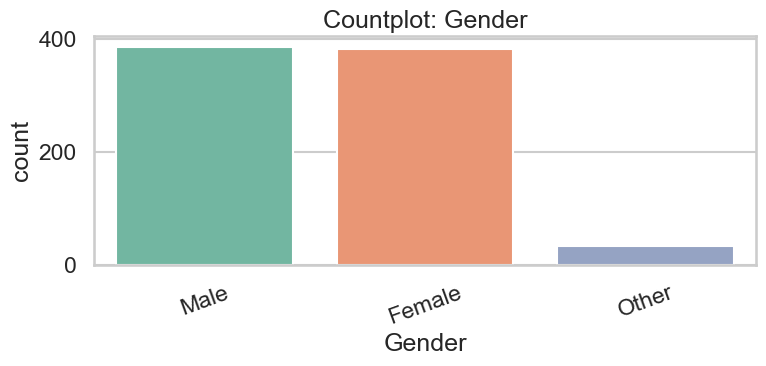

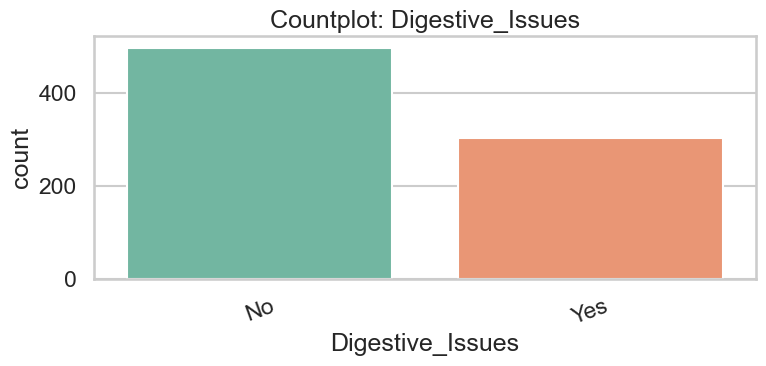

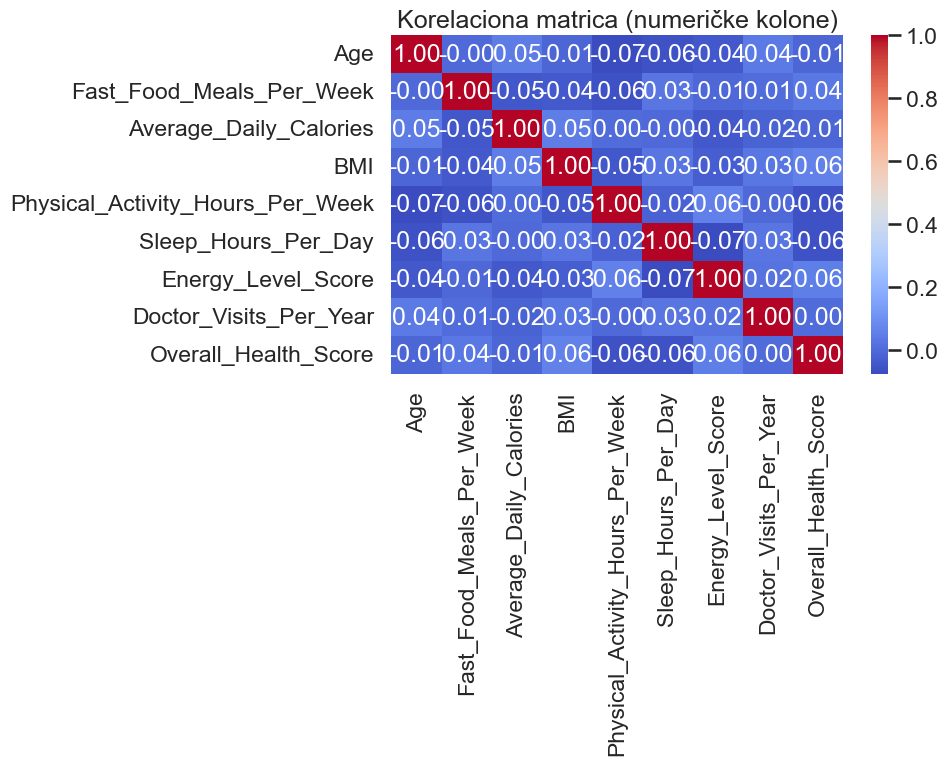

In [48]:
target_col = "Overall_Health_Score"

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# Histogram target promenljive
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[target_col], bins=20, kde=True, ax=ax, color="#1f77b4")
ax.set_title("Distribucija Overall_Health_Score")
figures["eda_target_hist"] = fig
plt.show()

# Boxplotovi numeričkih kolona
box_num_cols = [c for c in num_cols if c != target_col]
if box_num_cols:
    n = len(box_num_cols)
    fig, axes = plt.subplots(nrows=int(np.ceil(n / 3)), ncols=3, figsize=(18, 4 * int(np.ceil(n / 3))))
    axes = np.array(axes).reshape(-1)
    for i, c in enumerate(box_num_cols):
        sns.boxplot(y=df[c], ax=axes[i], color="#2ca02c")
        axes[i].set_title(f"Boxplot: {c}")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    fig.tight_layout()
    figures["eda_boxplots_numeric"] = fig
    plt.show()

# Countplot kategorijskih kolona
for c in cat_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    order = df[c].value_counts().index
    sns.countplot(data=df, x=c, order=order, ax=ax, palette="Set2")
    ax.set_title(f"Countplot: {c}")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    figures[f"eda_countplot_{c}"] = fig
    plt.show()

# Heatmap korelacije numeričkih kolona
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Korelaciona matrica (numeričke kolone)")
fig.tight_layout()
figures["eda_corr_heatmap"] = fig
plt.show()

## 5) Definisanje target-a (`overall_health_score`) i feature-a

In [49]:
if target_col not in df.columns:
    raise ValueError(f"Target kolona '{target_col}' ne postoji u dataset-u.")

if not np.issubdtype(df[target_col].dtype, np.number):
    raise TypeError("Target mora biti numerički za regresiju.")

X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Broj feature-a: {X.shape[1]}")
print("Feature kolone:")
display(pd.Series(X.columns, name="features"))
print("\nTarget statistika:")
display(y.describe())

Broj feature-a: 10
Feature kolone:


0                                 Age
1                              Gender
2            Fast_Food_Meals_Per_Week
3              Average_Daily_Calories
4                                 BMI
5    Physical_Activity_Hours_Per_Week
6                 Sleep_Hours_Per_Day
7                  Energy_Level_Score
8                    Digestive_Issues
9              Doctor_Visits_Per_Year
Name: features, dtype: object


Target statistika:


count    800.000000
mean       4.922500
std        2.681974
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max        9.000000
Name: Overall_Health_Score, dtype: float64

## 6) Preprocesing pipeline (numeričke + kategorijske kolone)

In [50]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numeričke kolone:", numeric_features)
print("Kategorijske kolone:", categorical_features)

Numeričke kolone: ['Age', 'Fast_Food_Meals_Per_Week', 'Average_Daily_Calories', 'BMI', 'Physical_Activity_Hours_Per_Week', 'Sleep_Hours_Per_Day', 'Energy_Level_Score', 'Doctor_Visits_Per_Year']
Kategorijske kolone: ['Gender', 'Digestive_Issues']


## 7) Podela skupa na train/validation/test

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (640, 10), Test shape: (160, 10)


In [52]:
def evaluate_regression_model(model_name, model, X_train, y_train, X_test, y_test, tolerance=1.0):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    reg_acc = np.mean(np.abs(y_test - y_pred) <= tolerance)

    results.append(
        {
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            f"Reg_Accuracy_±{tolerance}": reg_acc,
        }
    )
    model_predictions[model_name] = y_pred

    fig1, ax1 = plt.subplots(figsize=(7, 6))
    sns.scatterplot(x=y_test, y=y_pred, ax=ax1, alpha=0.75)
    min_v = min(y_test.min(), y_pred.min())
    max_v = max(y_test.max(), y_pred.max())
    ax1.plot([min_v, max_v], [min_v, max_v], color="red", linestyle="--")
    ax1.set_title(f"{model_name} | Stvarno vs Predvidjanje")
    ax1.set_xlabel("Stvarna vrednost")
    ax1.set_ylabel("Predvidjena vrednost")
    fig1.tight_layout()
    figures[f"{model_name}_actual_vs_pred"] = fig1
    plt.show()

    residuals = y_test - y_pred
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    sns.scatterplot(x=y_pred, y=residuals, ax=ax2, alpha=0.75)
    ax2.axhline(0, color="red", linestyle="--")
    ax2.set_title(f"{model_name} | Residual plot")
    ax2.set_xlabel("Predvidjena vrednost")
    ax2.set_ylabel("Residual")
    fig2.tight_layout()
    figures[f"{model_name}_residuals"] = fig2
    plt.show()

    print(
        f"{model_name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}, "
        f"Reg_Accuracy_±{tolerance}={reg_acc:.2%}"
    )
    return model

## 8) Model 1: Linearna regresija

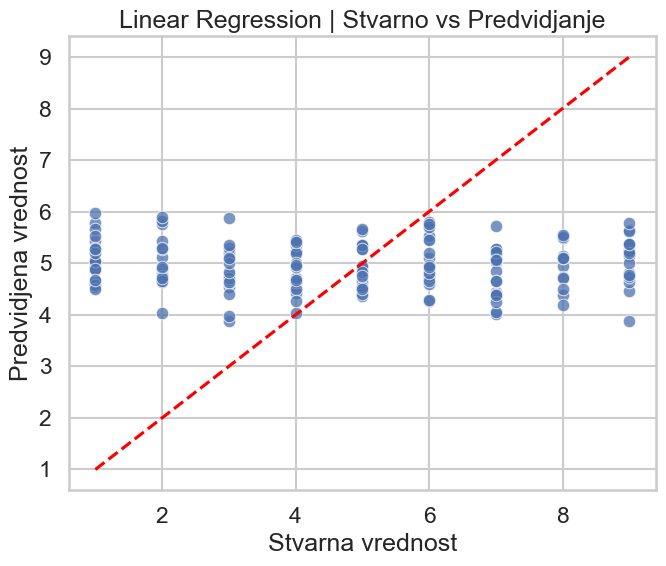

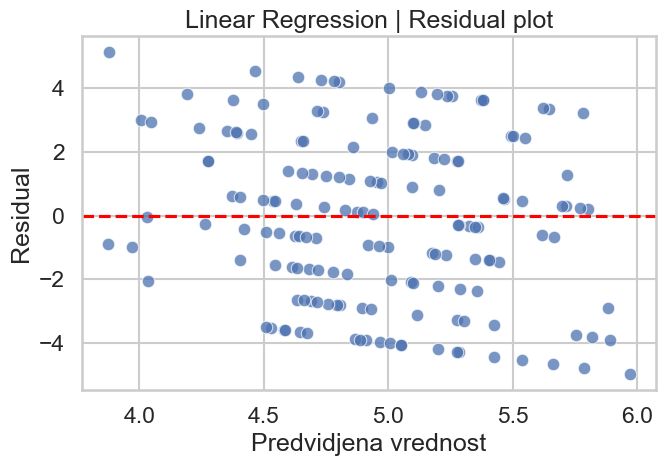

Linear Regression: MAE=2.2182, RMSE=2.6103, R2=-0.0405, Reg_Accuracy_±1.0=25.62%


In [53]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression()),
    ]
)

lr_model = evaluate_regression_model(
    "Linear Regression", lr_pipeline, X_train, y_train, X_test, y_test
)

## 9) Model 2: Random Forest Regressor

RF best params: {'model__max_depth': 8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 5, 'model__n_estimators': 500}


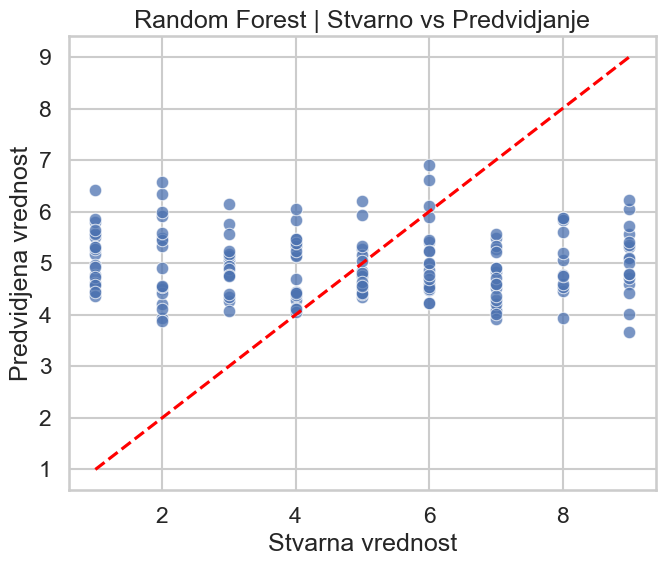

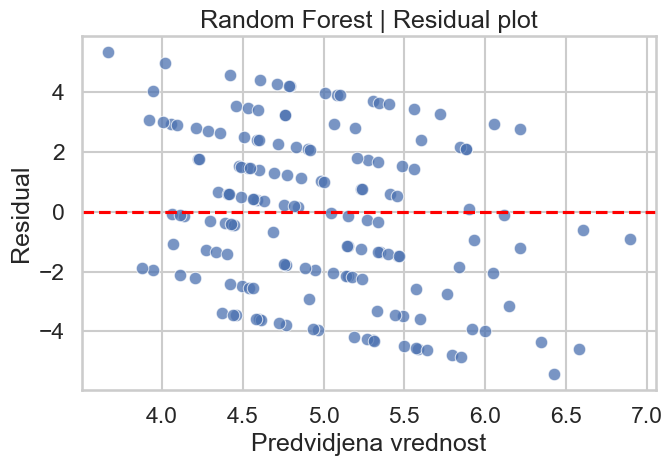

Random Forest: MAE=2.2838, RMSE=2.6810, R2=-0.0976, Reg_Accuracy_±1.0=21.88%


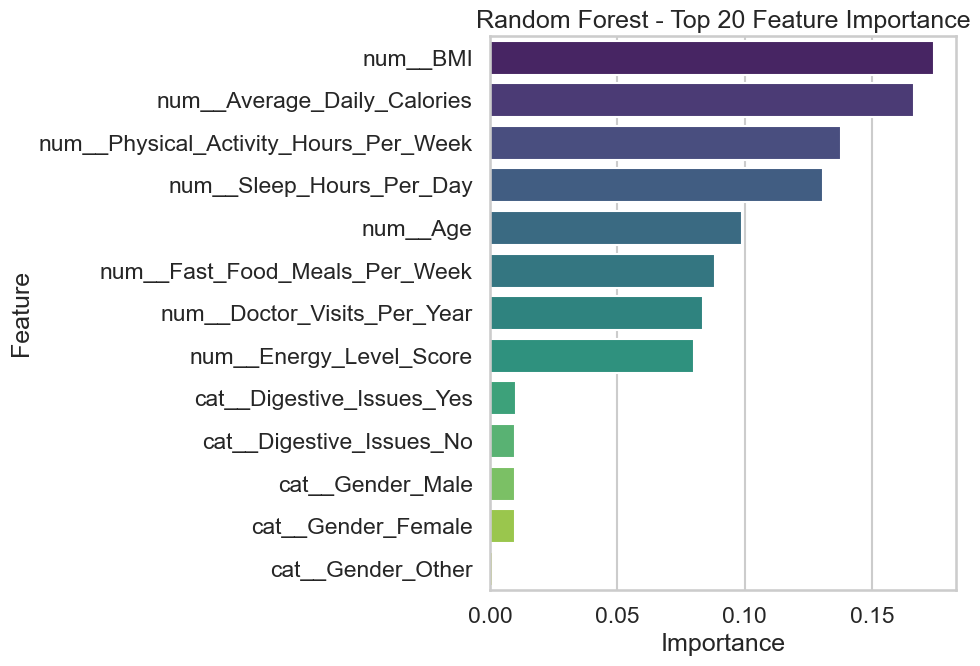

In [54]:
rf_base_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_param_grid = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4],
}

rf_search = GridSearchCV(
    estimator=rf_base_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print("RF best params:", rf_search.best_params_)

rf_model = evaluate_regression_model(
    "Random Forest", rf_search.best_estimator_, X_train, y_train, X_test, y_test
)

# Feature importance (RF)
rf_regressor = rf_model.named_steps["model"]
preprocessor_fitted = rf_model.named_steps["preprocess"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_regressor.feature_importances_

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importance_df, x="Importance", y="Feature", ax=ax, palette="viridis")
ax.set_title("Random Forest - Top 20 Feature Importance")
fig.tight_layout()
figures["random_forest_feature_importance"] = fig
plt.show()

## 10) Model 3: Gradient Boosting Regressor

GBR best params: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 1.0}


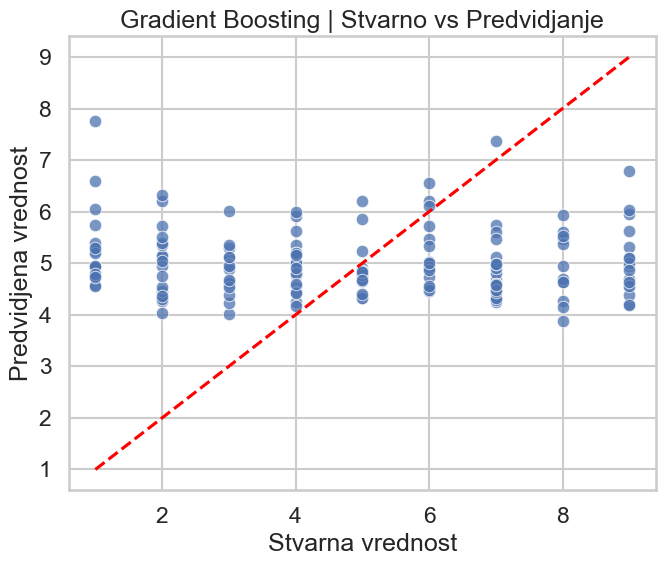

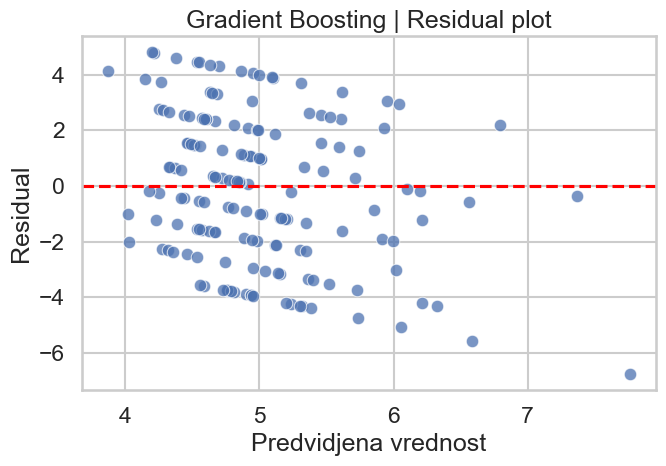

Gradient Boosting: MAE=2.2579, RMSE=2.6761, R2=-0.0936, Reg_Accuracy_±1.0=21.88%


In [55]:
gbr_base_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            GradientBoostingRegressor(
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

gbr_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
}

gbr_search = GridSearchCV(
    estimator=gbr_base_pipeline,
    param_grid=gbr_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
gbr_search.fit(X_train, y_train)
print("GBR best params:", gbr_search.best_params_)

gbr_model = evaluate_regression_model(
    "Gradient Boosting", gbr_search.best_estimator_, X_train, y_train, X_test, y_test
)

## 11) Model 4: SVR

SVR best params: {'model__C': 10, 'model__epsilon': 0.4, 'model__gamma': 0.05}


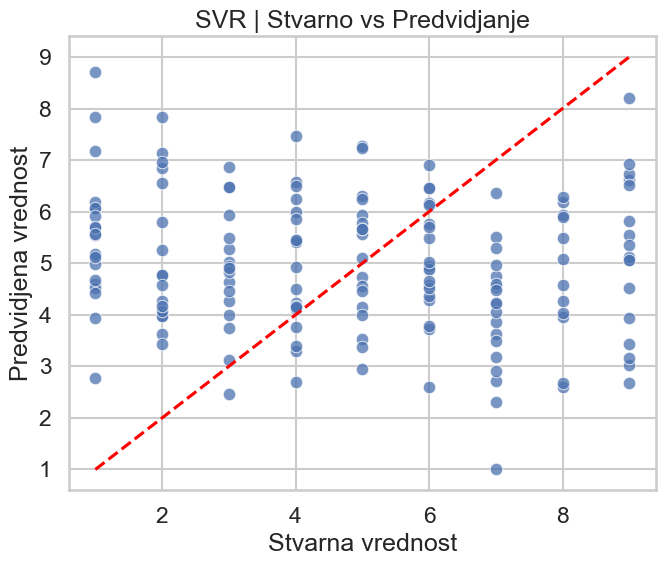

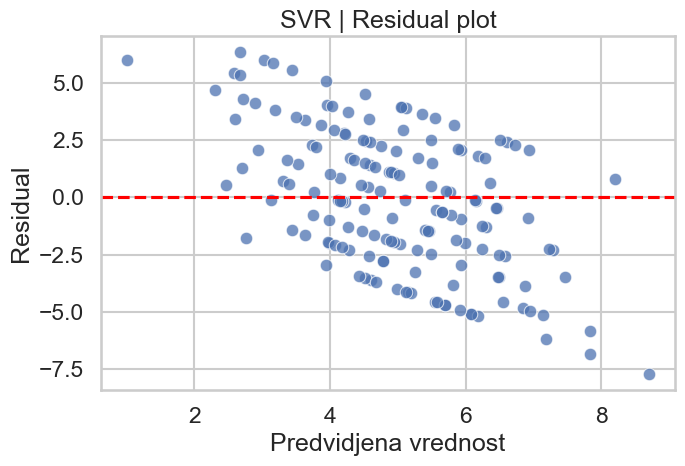

SVR: MAE=2.5563, RMSE=3.0572, R2=-0.4272, Reg_Accuracy_±1.0=21.25%


In [56]:
svr_base_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", SVR(kernel="rbf")),
    ]
)

svr_param_grid = {
    "model__C": [10, 25, 50, 100],
    "model__epsilon": [0.1, 0.2, 0.4],
    "model__gamma": ["scale", 0.05, 0.1],
}

svr_search = GridSearchCV(
    estimator=svr_base_pipeline,
    param_grid=svr_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
svr_search.fit(X_train, y_train)
print("SVR best params:", svr_search.best_params_)

svr_model = evaluate_regression_model(
    "SVR", svr_search.best_estimator_, X_train, y_train, X_test, y_test
)

## 12) Evaluacija modela (MAE, RMSE, $R^2$) i uporedni prikaz

,Model,MAE,RMSE,R2,Reg_Accuracy_±1.0
0,Linear Regression,2.218209,2.610300,-0.040478,0.25625
1,Gradient Boosting,2.257886,2.676062,-0.093564,0.21875
2,Random Forest,2.283805,2.681004,-0.097607,0.21875
3,SVR,2.556251,3.057156,-0.427207,0.21250


Najbolji model prema RMSE: Linear Regression


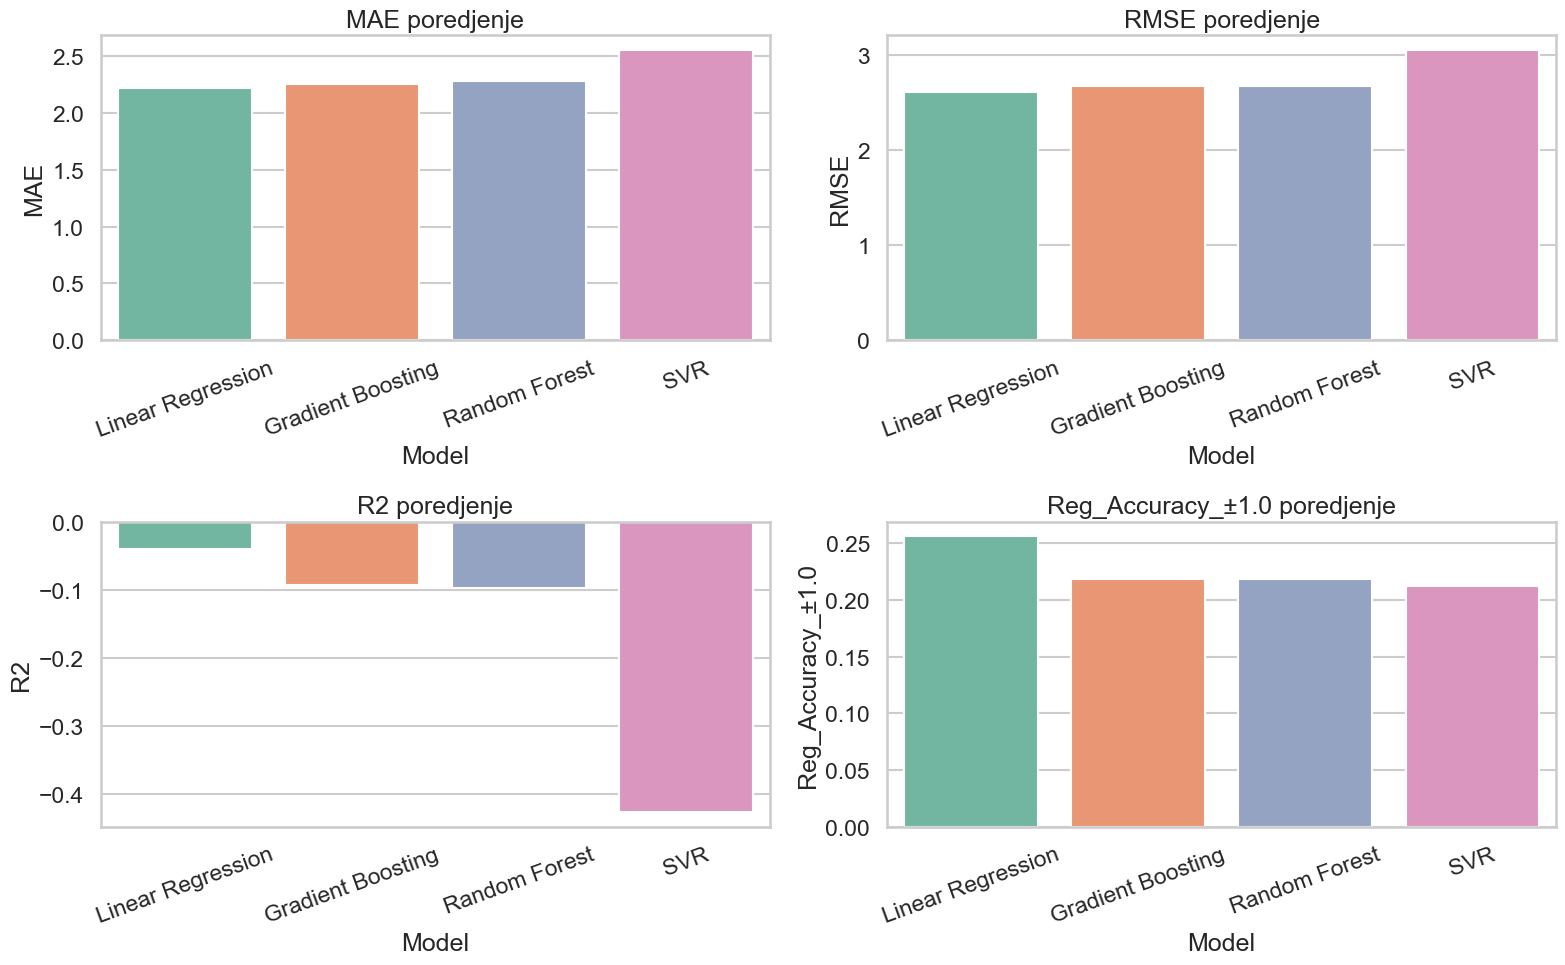

In [57]:
results_df = pd.DataFrame(results).sort_values(by="RMSE", ascending=True).reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"Najbolji model prema RMSE: {best_model_name}")

# Uporedni bar chart (ukljucena i regresiona accuracy)
metric_cols = ["MAE", "RMSE", "R2"]
reg_acc_cols = [c for c in results_df.columns if c.startswith("Reg_Accuracy_")]
if reg_acc_cols:
    metric_cols.extend(reg_acc_cols)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metric_cols):
    sns.barplot(data=results_df, x="Model", y=metric, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{metric} poredjenje")
    axes[i].tick_params(axis="x", rotation=20)

for j in range(len(metric_cols), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
figures["model_comparison_metrics"] = fig
plt.show()

## 13) Matrice konfuzije preko binovanja health score-a

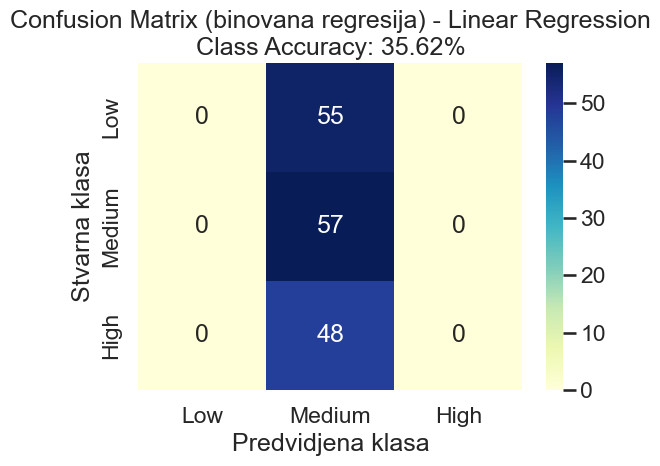

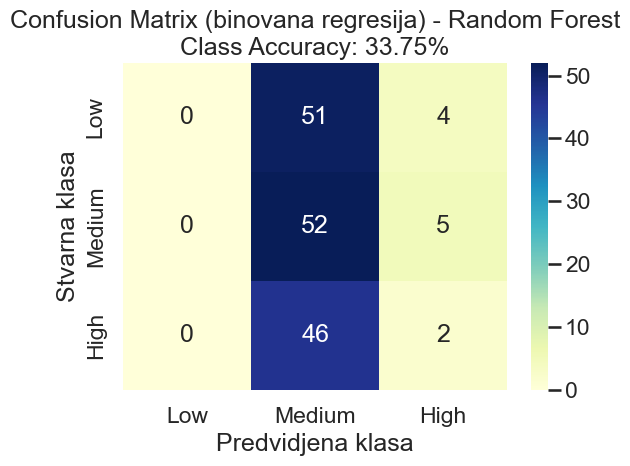

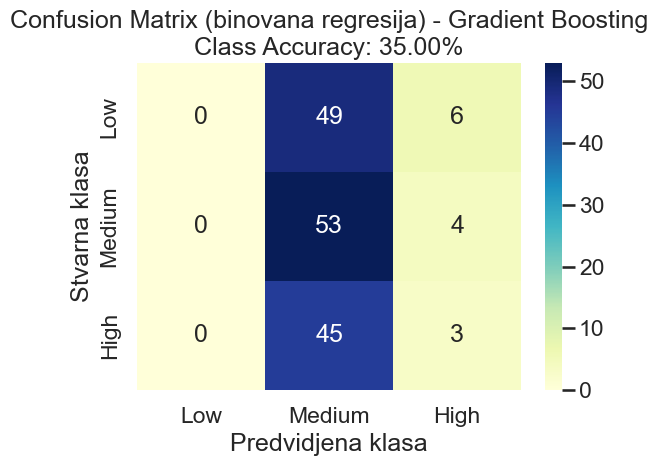

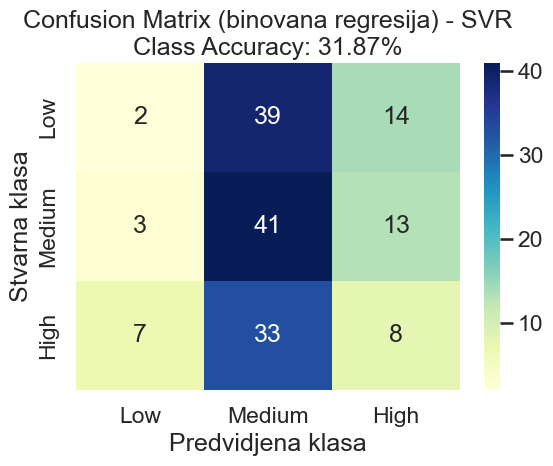

Tabela metrika sa dodatom klasifikacionom accuracy:


,Model,MAE,RMSE,R2,Reg_Accuracy_±1.0,Class_Accuracy
0,Linear Regression,2.218209,2.610300,-0.040478,0.25625,0.35625
1,Gradient Boosting,2.257886,2.676062,-0.093564,0.21875,0.35000
2,Random Forest,2.283805,2.681004,-0.097607,0.21875,0.33750
3,SVR,2.556251,3.057156,-0.427207,0.21250,0.31875


In [58]:
# Pragovi po tercilima trening skupa
q1, q2 = np.quantile(y_train, [0.33, 0.66])
bins = [-np.inf, q1, q2, np.inf]
class_labels = ["Low", "Medium", "High"]


def to_classes(values, bins, labels):
    idx = np.digitize(values, bins[1:-1], right=True)
    return np.array([labels[i] for i in idx])


y_true_cls = to_classes(y_test.values, bins, class_labels)

for model_name, y_pred in model_predictions.items():
    y_pred_cls = to_classes(y_pred, bins, class_labels)
    cm = confusion_matrix(y_true_cls, y_pred_cls, labels=class_labels)

    cls_acc = accuracy_score(y_true_cls, y_pred_cls)
    class_accuracies[model_name] = cls_acc

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix (binovana regresija) - {model_name}\nClass Accuracy: {cls_acc:.2%}")
    ax.set_xlabel("Predvidjena klasa")
    ax.set_ylabel("Stvarna klasa")
    fig.tight_layout()
    figures[f"confusion_matrix_{model_name.replace(' ', '_').lower()}"] = fig
    plt.show()

# Dodaj klasifikacionu accuracy u zbirnu tabelu
results_df["Class_Accuracy"] = results_df["Model"].map(class_accuracies)
print("Tabela metrika sa dodatom klasifikacionom accuracy:")
display(results_df.sort_values(by="Class_Accuracy", ascending=False))

## 14) Sekcija za prezentaciju: čuvanje/štampanje grafika, matrica i tabela rezultata

In [59]:
# Kreiranje output foldera
output_figures = os.path.join("outputs", "figures")
output_tables = os.path.join("outputs", "tables")
os.makedirs(output_figures, exist_ok=True)
os.makedirs(output_tables, exist_ok=True)

# Snimanje svih figura u visokoj rezoluciji (za štampu)
for fig_name, fig_obj in figures.items():
    save_path = os.path.join(output_figures, f"{fig_name}.png")
    fig_obj.savefig(save_path, dpi=300, bbox_inches="tight")

# Snimanje tabela rezultata
results_df.to_csv(os.path.join(output_tables, "model_metrics.csv"), index=False)

# Dodatni pregled: top model i pragovi binovanja
summary_df = pd.DataFrame(
    {
        "best_model": [best_model_name],
        "bin_low_to_medium_threshold": [q1],
        "bin_medium_to_high_threshold": [q2],
    }
)
summary_df.to_csv(os.path.join(output_tables, "presentation_summary.csv"), index=False)

print(f"Broj sačuvanih figura: {len(figures)}")
print(f"Figure folder: {output_figures}")
print(f"Tabele folder: {output_tables}")

display(results_df)
display(summary_df)

Broj sačuvanih figura: 19
Figure folder: outputs\figures
Tabele folder: outputs\tables


,Model,MAE,RMSE,R2,Reg_Accuracy_±1.0,Class_Accuracy
0,Linear Regression,2.218209,2.610300,-0.040478,0.25625,0.35625
1,Gradient Boosting,2.257886,2.676062,-0.093564,0.21875,0.35000
2,Random Forest,2.283805,2.681004,-0.097607,0.21875,0.33750
3,SVR,2.556251,3.057156,-0.427207,0.21250,0.31875


,best_model,bin_low_to_medium_threshold,bin_medium_to_high_threshold
0,Linear Regression,3.0,6.0
